# Tech Challenge Fase 4 — Classificação do Nível de Obesidade

Este notebook desenvolve uma pipeline de Machine Learning para prever o nível de obesidade de uma pessoa a partir de variáveis físicas, demográficas e comportamentais.

A solução foi construída de forma simples e defensável, seguindo os principais requisitos do desafio:

- análise exploratória dos dados;
- feature engineering;
- treinamento e comparação de modelos;
- avaliação do melhor modelo;
- salvamento da pipeline para uso posterior em uma aplicação Streamlit.

> Observação: o modelo é uma ferramenta de apoio à decisão e não substitui avaliação médica profissional.

## 1. Importação das bibliotecas

Nesta etapa são carregadas as bibliotecas usadas para manipulação dos dados, visualizações, modelagem e salvamento da pipeline.

In [1]:
# Manipulação e análise de dados
import os
import joblib
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Modelagem
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Configurações visuais e de exibição
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 2. Leitura da base

A base utilizada no desafio é o arquivo `Obesity.csv`. No enunciado, a variável alvo é citada como `Obesity_level`, mas no arquivo disponibilizado a coluna correspondente está nomeada como `Obesity`.

In [2]:
# Caminhos possíveis para facilitar o uso no Colab ou localmente
arquivos_possiveis = [
    "Obesity.csv",
    "Obesity(1).csv",
    "/content/Obesity.csv",
    "/content/Obesity(1).csv",
    "/mnt/data/Obesity.csv",
    "/mnt/data/Obesity(1).csv"
]

arquivo = None

for caminho in arquivos_possiveis:
    if os.path.exists(caminho):
        arquivo = caminho
        break

# Caso o arquivo não esteja no ambiente, tenta abrir o upload manual do Colab
if arquivo is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        arquivo = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError("Arquivo Obesity.csv não encontrado. Faça o upload do arquivo no ambiente.")

df_original = pd.read_csv(arquivo)
df = df_original.copy()

print(f"Arquivo utilizado: {arquivo}")
print("Dimensão inicial da base:", df.shape)

display(df.head())

Arquivo utilizado: Obesity.csv
Dimensão inicial da base: (2111, 17)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.00,1.62,64.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,0.00,1.00,no,Public_Transportation,Normal_Weight
1,Female,21.00,1.52,56.00,yes,no,3.00,3.00,Sometimes,yes,3.00,yes,3.00,0.00,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.00,1.80,77.00,yes,no,2.00,3.00,Sometimes,no,2.00,no,2.00,1.00,Frequently,Public_Transportation,Normal_Weight
3,Male,27.00,1.80,87.00,no,no,3.00,3.00,Sometimes,no,2.00,no,2.00,0.00,Frequently,Walking,Overweight_Level_I
4,Male,22.00,1.78,89.80,no,no,2.00,1.00,Sometimes,no,2.00,no,0.00,0.00,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Entendimento inicial dos dados

O objetivo desta etapa é verificar estrutura, tipos de dados, valores nulos, quantidade de categorias e duplicatas.

In [3]:
# Estrutura da base
print("Colunas da base:")
print(df.columns.tolist())

print("\nInformações gerais:")
df.info()

Colunas da base:
['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'Obesity']

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 

In [4]:
# Diagnóstico de qualidade
resumo_qualidade = pd.DataFrame({
    "tipo_dado": df.dtypes,
    "valores_nulos": df.isnull().sum(),
    "percentual_nulos": (df.isnull().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(resumo_qualidade)

print("Quantidade de linhas duplicadas:", df.duplicated().sum())

,tipo_dado,valores_nulos,percentual_nulos,valores_unicos
Gender,object,0,0.00,2
Age,float64,0,0.00,1402
Height,float64,0,0.00,1574
Weight,float64,0,0.00,1525
family_history,object,0,0.00,2
FAVC,object,0,0.00,2
FCVC,float64,0,0.00,810
NCP,float64,0,0.00,635
CAEC,object,0,0.00,4
SMOKE,object,0,0.00,2


Quantidade de linhas duplicadas: 24


### Ajustes iniciais

A base não apresenta valores nulos aparentes. Foram identificadas duplicatas exatas, que serão removidas para evitar que o mesmo registro apareça em treino e teste.

In [5]:
# Remoção de duplicatas exatas
linhas_antes = df.shape[0]
duplicatas = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

print(f"Linhas antes da remoção: {linhas_antes}")
print(f"Duplicatas removidas: {duplicatas}")
print(f"Linhas após a remoção: {df.shape[0]}")

Linhas antes da remoção: 2111
Duplicatas removidas: 24
Linhas após a remoção: 2087


## 4. Feature engineering

Foi criada a variável `BMI`, equivalente ao IMC, calculada a partir da relação entre peso e altura:

\[
BMI = \frac{Weight}{Height^2}
\]

Essa variável é relevante porque resume a relação corporal entre massa e estatura.

In [6]:
# Criação da variável BMI/IMC
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

display(df[["Height", "Weight", "BMI", "Obesity"]].head())

print("Resumo estatístico do BMI:")
display(df["BMI"].describe())

,Height,Weight,BMI,Obesity
0,1.62,64.00,24.39,Normal_Weight
1,1.52,56.00,24.24,Normal_Weight
2,1.80,77.00,23.77,Normal_Weight
3,1.80,87.00,26.85,Overweight_Level_I
4,1.78,89.80,28.34,Overweight_Level_II


Resumo estatístico do BMI:


count   2087.00
mean      29.77
std        8.02
min       13.00
25%       24.37
50%       28.90
75%       36.10
max       50.81
Name: BMI, dtype: float64

## 5. Preparação de rótulos para análise

O modelo será treinado com as sete classes originais da base. Para facilitar a comunicação dos resultados no dashboard, também foi criada uma versão simplificada com quatro grupos.

In [7]:
# Ordem lógica das classes originais
ordem_obesidade = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]

# Tradução das classes para visualização
traducao_classes = {
    "Insufficient_Weight": "Abaixo do Peso",
    "Normal_Weight": "Peso Normal",
    "Overweight_Level_I": "Sobrepeso Nível I",
    "Overweight_Level_II": "Sobrepeso Nível II",
    "Obesity_Type_I": "Obesidade Tipo I",
    "Obesity_Type_II": "Obesidade Tipo II",
    "Obesity_Type_III": "Obesidade Tipo III"
}

# Agrupamento simplificado para análise executiva
mapa_obesidade_simplificado = {
    "Insufficient_Weight": "Abaixo do Peso",
    "Normal_Weight": "Peso Normal",
    "Overweight_Level_I": "Sobrepeso",
    "Overweight_Level_II": "Sobrepeso",
    "Obesity_Type_I": "Obesidade",
    "Obesity_Type_II": "Obesidade",
    "Obesity_Type_III": "Obesidade"
}

ordem_grupo = [
    "Abaixo do Peso",
    "Peso Normal",
    "Sobrepeso",
    "Obesidade"
]

# Criação das colunas auxiliares
df["Obesity_Group"] = df["Obesity"].map(mapa_obesidade_simplificado)
df["Obesity_PT"] = df["Obesity"].map(traducao_classes)

# Definição de categorias ordenadas para visualização
df["Obesity"] = pd.Categorical(df["Obesity"], categories=ordem_obesidade, ordered=True)
df["Obesity_Group"] = pd.Categorical(df["Obesity_Group"], categories=ordem_grupo, ordered=True)

display(df[["Obesity", "Obesity_PT", "Obesity_Group"]].head())

,Obesity,Obesity_PT,Obesity_Group
0,Normal_Weight,Peso Normal,Peso Normal
1,Normal_Weight,Peso Normal,Peso Normal
2,Normal_Weight,Peso Normal,Peso Normal
3,Overweight_Level_I,Sobrepeso Nível I,Sobrepeso
4,Overweight_Level_II,Sobrepeso Nível II,Sobrepeso


## 6. Análise exploratória dos dados

A análise exploratória foi mantida objetiva, com foco em pontos úteis para o modelo e para a visão de negócio.

In [8]:
# Distribuição da variável alvo
distribuicao_target = (
    df["Obesity"]
    .value_counts()
    .reindex(ordem_obesidade)
    .reset_index()
)

distribuicao_target.columns = ["classe", "quantidade"]
distribuicao_target["classe_pt"] = distribuicao_target["classe"].map(traducao_classes)
distribuicao_target["percentual"] = (
    distribuicao_target["quantidade"] / len(df) * 100
).round(2)

display(distribuicao_target[["classe_pt", "quantidade", "percentual"]])

,classe_pt,quantidade,percentual
0,Abaixo do Peso,267,12.79
1,Peso Normal,282,13.51
2,Sobrepeso Nível I,276,13.22
3,Sobrepeso Nível II,290,13.90
4,Obesidade Tipo I,351,16.82
5,Obesidade Tipo II,297,14.23
6,Obesidade Tipo III,324,15.52


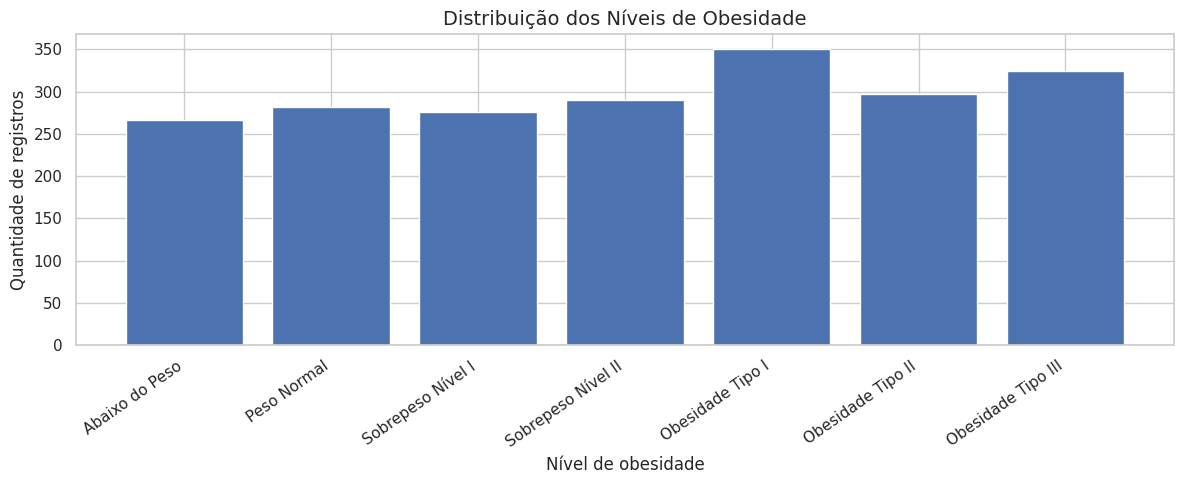

In [9]:
# Gráfico: distribuição das 7 classes
plot_df = distribuicao_target.copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["classe_pt"], plot_df["quantidade"])

plt.title("Distribuição dos Níveis de Obesidade", fontsize=14)
plt.xlabel("Nível de obesidade")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [10]:
# Distribuição dos grupos simplificados
distribuicao_grupos = (
    df["Obesity_Group"]
    .value_counts()
    .reindex(ordem_grupo)
    .reset_index()
)

distribuicao_grupos.columns = ["grupo", "quantidade"]
distribuicao_grupos["percentual"] = (
    distribuicao_grupos["quantidade"] / len(df) * 100
).round(2)

display(distribuicao_grupos)

,grupo,quantidade,percentual
0,Abaixo do Peso,267,12.79
1,Peso Normal,282,13.51
2,Sobrepeso,566,27.12
3,Obesidade,972,46.57


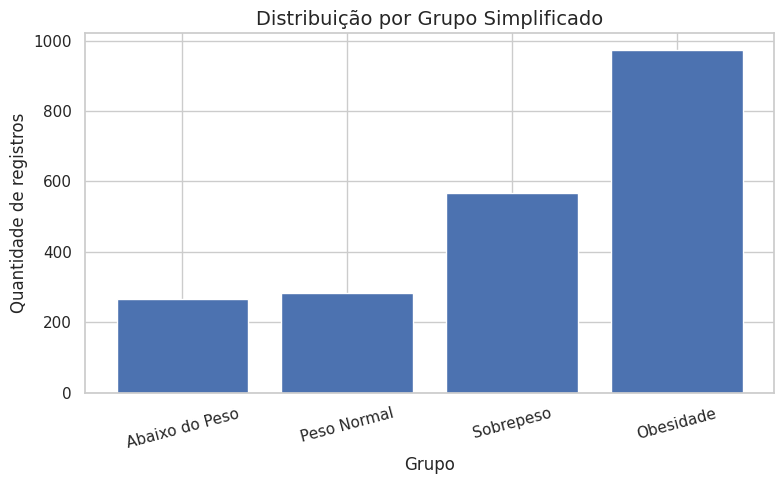

In [11]:
# Gráfico: distribuição dos grupos simplificados
plot_df = distribuicao_grupos.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["grupo"], plot_df["quantidade"])

plt.title("Distribuição por Grupo Simplificado", fontsize=14)
plt.xlabel("Grupo")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Relação entre variáveis corporais e obesidade

O IMC e o peso tendem a crescer de forma consistente conforme o nível de obesidade aumenta. Esse comportamento é esperado e ajuda a explicar a alta relevância dessas variáveis na modelagem.

In [12]:
# IMC médio por classe
imc_por_classe = (
    df.groupby("Obesity", observed=True)["BMI"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
    .reset_index()
)

imc_por_classe["classe_pt"] = imc_por_classe["Obesity"].map(traducao_classes)

display(imc_por_classe[["classe_pt", "mean", "median", "min", "max"]])

,classe_pt,mean,median,min,max
0,Abaixo do Peso,17.39,17.53,13.00,19.08
1,Peso Normal,22.01,22.12,18.49,24.91
2,Sobrepeso Nível I,25.96,25.95,22.83,28.77
3,Sobrepeso Nível II,28.22,28.15,25.71,30.36
4,Obesidade Tipo I,32.26,32.20,29.91,35.17
5,Obesidade Tipo II,36.72,36.42,34.05,39.79
6,Obesidade Tipo III,42.27,41.94,36.77,50.81


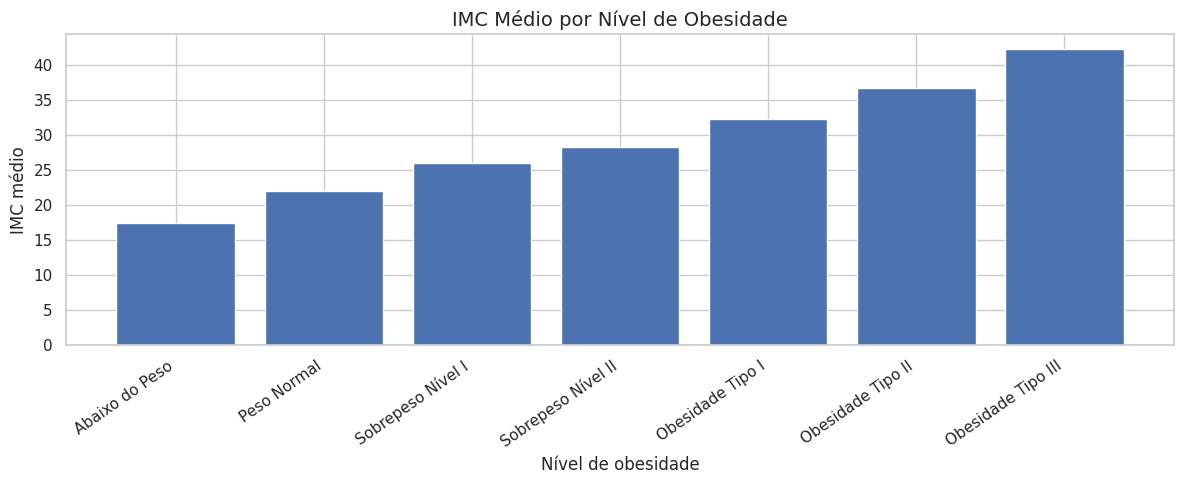

In [13]:
# Gráfico: IMC médio por classe
plot_df = imc_por_classe.copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["classe_pt"], plot_df["mean"])

plt.title("IMC Médio por Nível de Obesidade", fontsize=14)
plt.xlabel("Nível de obesidade")
plt.ylabel("IMC médio")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

/tmp/ipykernel_4441/3693642527.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(dados_boxplot, labels=classes_pt_ordenadas, showfliers=True)


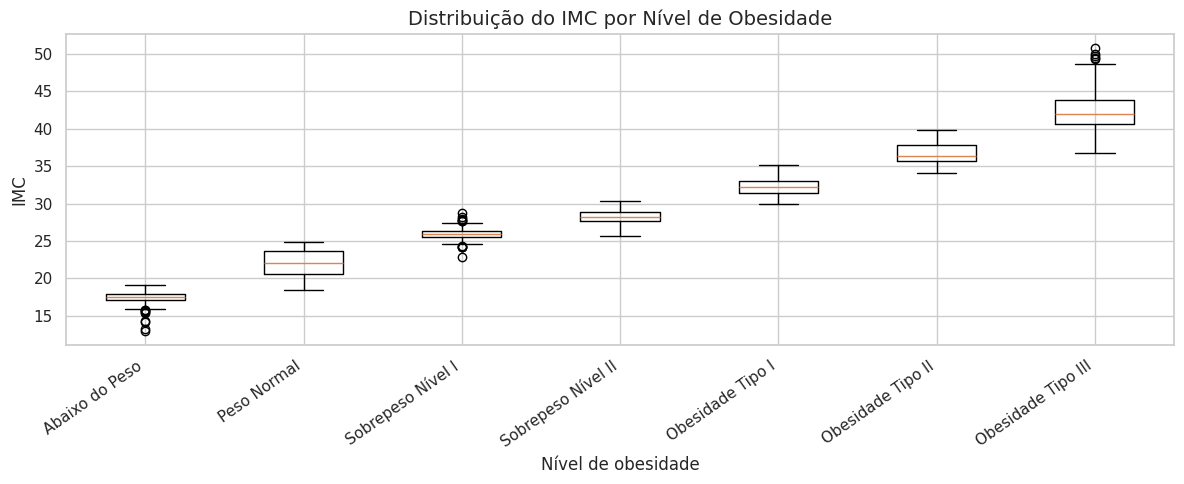

In [14]:
# Gráfico: distribuição do IMC por classe
classes_pt_ordenadas = [traducao_classes[c] for c in ordem_obesidade]

dados_boxplot = [
    df.loc[df["Obesity_PT"] == classe, "BMI"]
    for classe in classes_pt_ordenadas
]

plt.figure(figsize=(12, 5))
plt.boxplot(dados_boxplot, labels=classes_pt_ordenadas, showfliers=True)

plt.title("Distribuição do IMC por Nível de Obesidade", fontsize=14)
plt.xlabel("Nível de obesidade")
plt.ylabel("IMC")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [15]:
# Peso médio por classe
peso_por_classe = (
    df.groupby("Obesity", observed=True)["Weight"]
    .agg(["mean", "median", "min", "max"])
    .round(2)
    .reset_index()
)

peso_por_classe["classe_pt"] = peso_por_classe["Obesity"].map(traducao_classes)

display(peso_por_classe[["classe_pt", "mean", "median", "min", "max"]])

,classe_pt,mean,median,min,max
0,Abaixo do Peso,50.01,50.00,39.00,65.00
1,Peso Normal,62.16,61.00,42.30,87.00
2,Sobrepeso Nível I,74.48,75.00,53.00,91.00
3,Sobrepeso Nível II,82.09,82.00,60.00,102.00
4,Obesidade Tipo I,92.87,90.74,75.00,125.00
5,Obesidade Tipo II,115.31,117.79,93.00,130.00
6,Obesidade Tipo III,120.94,112.05,102.00,173.00


### Relação entre hábitos e grupos de obesidade

As variáveis comportamentais ajudam a trazer uma leitura mais analítica para o estudo, principalmente histórico familiar, consumo de alimentos calóricos e prática de atividade física.

In [16]:
# Histórico familiar por grupo simplificado
tabela_family = pd.crosstab(
    df["family_history"].replace({"yes": "Sim", "no": "Não"}),
    df["Obesity_Group"],
    normalize="index"
) * 100

display(tabela_family.round(2))

Obesity_Group,Abaixo do Peso,Peso Normal,Sobrepeso,Obesidade
family_history,,,,
Não,38.90,35.62,23.29,2.19
Sim,7.26,8.83,27.93,55.98


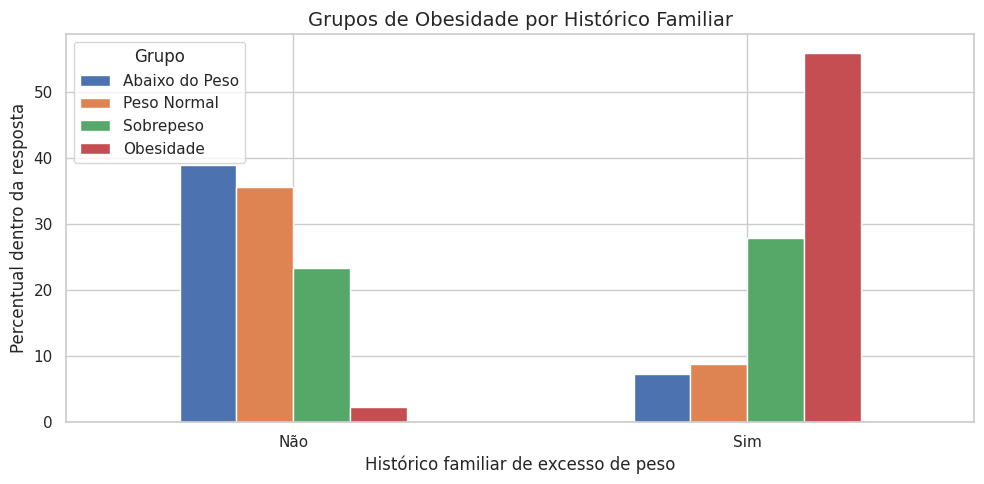

In [17]:
# Gráfico: histórico familiar por grupo simplificado
tabela_family_plot = tabela_family.reindex(columns=ordem_grupo)

ax = tabela_family_plot.plot(kind="bar", figsize=(10, 5))

plt.title("Grupos de Obesidade por Histórico Familiar", fontsize=14)
plt.xlabel("Histórico familiar de excesso de peso")
plt.ylabel("Percentual dentro da resposta")
plt.xticks(rotation=0)
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()

In [18]:
# Consumo de alimentos calóricos por grupo simplificado
tabela_favc = pd.crosstab(
    df["FAVC"].replace({"yes": "Sim", "no": "Não"}),
    df["Obesity_Group"],
    normalize="index"
) * 100

display(tabela_favc.round(2))

Obesity_Group,Abaixo do Peso,Peso Normal,Sobrepeso,Obesidade
FAVC,,,,
Não,20.58,32.10,39.51,7.82
Sim,11.77,11.06,25.49,51.68


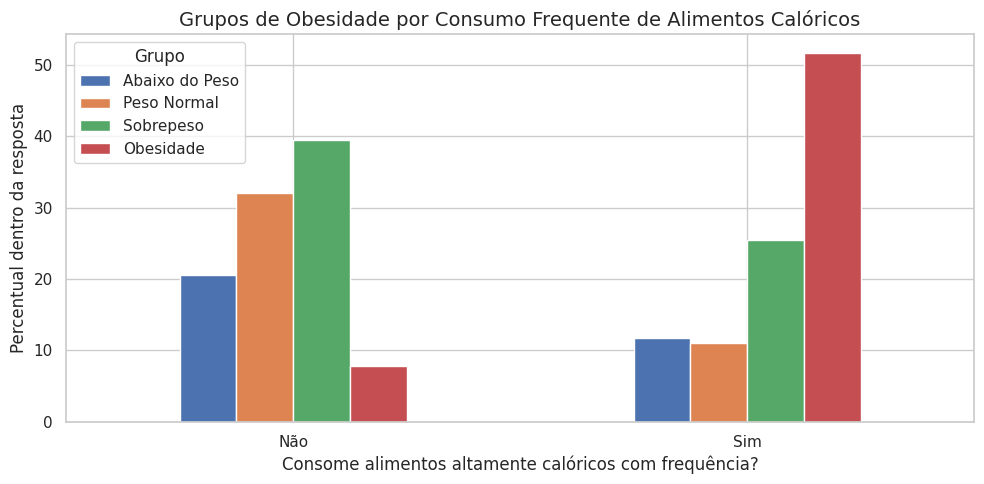

In [19]:
# Gráfico: consumo de alimentos calóricos por grupo
tabela_favc_plot = tabela_favc.reindex(columns=ordem_grupo)

ax = tabela_favc_plot.plot(kind="bar", figsize=(10, 5))

plt.title("Grupos de Obesidade por Consumo Frequente de Alimentos Calóricos", fontsize=14)
plt.xlabel("Consome alimentos altamente calóricos com frequência?")
plt.ylabel("Percentual dentro da resposta")
plt.xticks(rotation=0)
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()

In [20]:
# Atividade física média por classe
faf_por_classe = (
    df.groupby("Obesity", observed=True)["FAF"]
    .mean()
    .round(2)
    .reset_index()
)

faf_por_classe["classe_pt"] = faf_por_classe["Obesity"].map(traducao_classes)

display(faf_por_classe[["classe_pt", "FAF"]])

,classe_pt,FAF
0,Abaixo do Peso,1.27
1,Peso Normal,1.25
2,Sobrepeso Nível I,1.06
3,Sobrepeso Nível II,0.96
4,Obesidade Tipo I,0.99
5,Obesidade Tipo II,0.97
6,Obesidade Tipo III,0.66


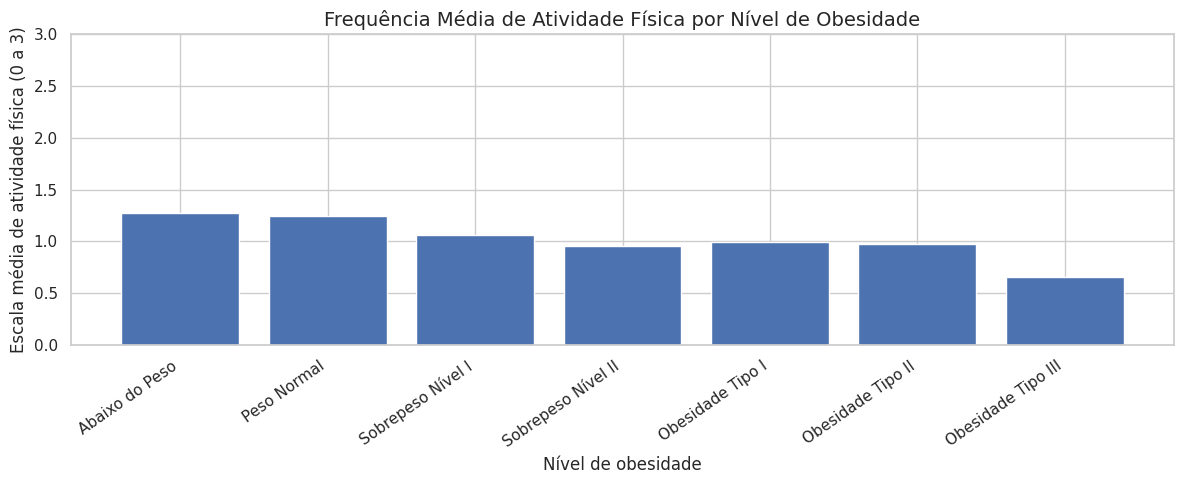

In [21]:
# Gráfico: atividade física média por classe
plot_df = faf_por_classe.copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["classe_pt"], plot_df["FAF"])

plt.title("Frequência Média de Atividade Física por Nível de Obesidade", fontsize=14)
plt.xlabel("Nível de obesidade")
plt.ylabel("Escala média de atividade física (0 a 3)")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 3)
plt.tight_layout()
plt.show()

**Interpretação da escala FAF:**  
0 = nenhuma atividade física; 1 = cerca de 1 a 2 vezes por semana; 2 = cerca de 3 a 4 vezes por semana; 3 = 5 vezes ou mais por semana.

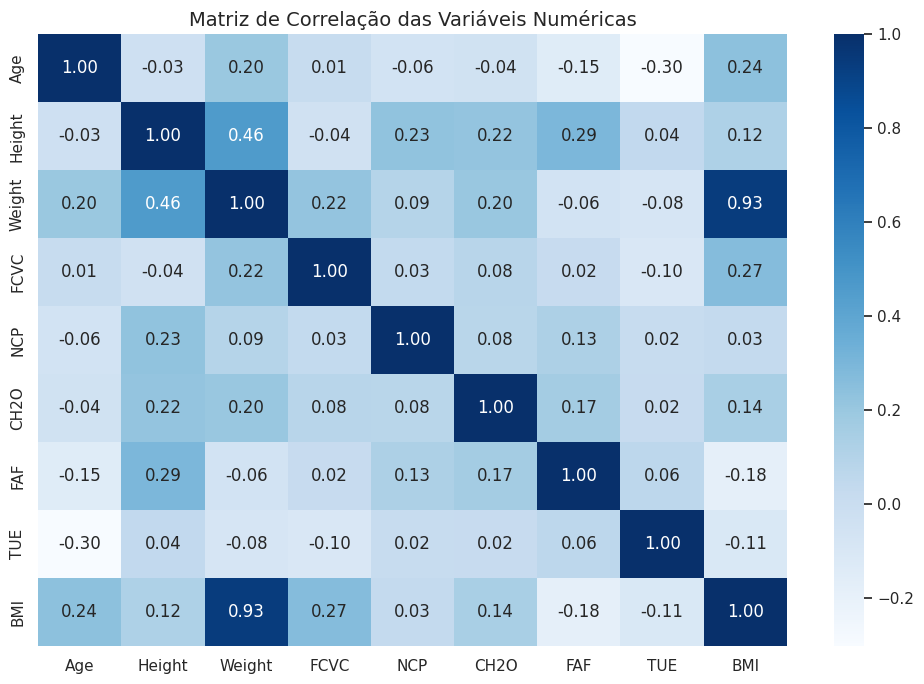

In [22]:
# Correlação entre variáveis numéricas
variaveis_numericas_eda = [
    "Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE", "BMI"
]

plt.figure(figsize=(10, 7))

correlacao = df[variaveis_numericas_eda].corr()

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Matriz de Correlação das Variáveis Numéricas", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Preparação para modelagem

A variável alvo do modelo será `Obesity`, mantendo as sete classes originais. A coluna `Obesity_Group` será usada apenas para análise e dashboard, não para treinamento.

In [23]:
# Separação entre variáveis explicativas e alvo
target = "Obesity"

colunas_excluir = ["Obesity", "Obesity_Group", "Obesity_PT"]

X = df.drop(columns=colunas_excluir)
y = df[target].astype(str)

variaveis_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
variaveis_categoricas = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

print("\nVariáveis numéricas:")
print(variaveis_numericas)

print("\nVariáveis categóricas:")
print(variaveis_categoricas)

Dimensão de X: (2087, 17)
Dimensão de y: (2087,)

Variáveis numéricas:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI']

Variáveis categóricas:
['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


In [24]:
# Separação treino/teste com estratificação das classes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDistribuição no teste:")
display(y_test.value_counts(normalize=True).mul(100).round(2).reset_index())

X_train: (1669, 17)
X_test: (418, 17)

Distribuição no teste:


,Obesity,proportion
0,Obesity_Type_I,16.75
1,Obesity_Type_III,15.55
2,Obesity_Type_II,14.35
3,Overweight_Level_II,13.88
4,Normal_Weight,13.64
5,Overweight_Level_I,13.16
6,Insufficient_Weight,12.68


## 8. Pipeline de pré-processamento

A pipeline trata automaticamente variáveis numéricas e categóricas. Isso facilita o uso posterior do modelo dentro da aplicação Streamlit.

In [25]:
# Tratamento das variáveis numéricas
pipeline_numerica = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Tratamento das variáveis categóricas
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

pipeline_categorica = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

# Pré-processador geral
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerica, variaveis_numericas),
        ("cat", pipeline_categorica, variaveis_categoricas)
    ]
)

print("Pré-processador criado com sucesso.")

Pré-processador criado com sucesso.


## 9. Treinamento dos modelos

Foram testados três modelos:

- **Logistic Regression:** modelo de referência simples;
- **Decision Tree:** modelo interpretável, mas mais sujeito a overfitting;
- **Random Forest:** modelo robusto para dados tabulares e escolhido como principal candidato.

In [26]:
# Definição dos modelos candidatos
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

print("Modelos definidos:")
for nome in modelos.keys():
    print("-", nome)

Modelos definidos:
- Logistic Regression
- Decision Tree
- Random Forest


In [27]:
# Treinamento e comparação dos modelos
resultados = []
pipelines_treinadas = {}

for nome_modelo, modelo in modelos.items():

    print(f"Treinando modelo: {nome_modelo}")

    pipeline = Pipeline(steps=[
        ("preprocessador", preprocessador),
        ("modelo", modelo)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    resultados.append({
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0)
    })

    pipelines_treinadas[nome_modelo] = pipeline

resultados_modelos = (
    pd.DataFrame(resultados)
    .sort_values(by="accuracy", ascending=False)
    .reset_index(drop=True)
)

display(resultados_modelos)

Treinando modelo: Logistic Regression
Treinando modelo: Decision Tree
Treinando modelo: Random Forest


,modelo,accuracy,f1_macro,precision_macro,recall_macro
0,Random Forest,0.98,0.98,0.98,0.98
1,Decision Tree,0.97,0.97,0.97,0.97
2,Logistic Regression,0.93,0.92,0.92,0.92


In [28]:
# Tabela em português para apresentação
resultados_modelos_pt = resultados_modelos.rename(columns={
    "modelo": "Modelo",
    "accuracy": "Acurácia",
    "f1_macro": "F1-score Macro",
    "precision_macro": "Precisão Macro",
    "recall_macro": "Recall Macro"
}).copy()

for coluna in ["Acurácia", "F1-score Macro", "Precisão Macro", "Recall Macro"]:
    resultados_modelos_pt[coluna] = (resultados_modelos_pt[coluna] * 100).round(2)

display(resultados_modelos_pt)

,Modelo,Acurácia,F1-score Macro,Precisão Macro,Recall Macro
0,Random Forest,98.09,98.04,98.15,98.04
1,Decision Tree,96.89,96.81,96.85,96.78
2,Logistic Regression,92.58,92.30,92.28,92.42


## 10. Seleção e avaliação do modelo final

O modelo com melhor desempenho será selecionado automaticamente com base na acurácia. A avaliação final considera acurácia, F1-score, matriz de confusão e ROC AUC multiclasse.

In [29]:
# Seleção do melhor modelo
melhor_modelo_nome = resultados_modelos.iloc[0]["modelo"]
melhor_pipeline = pipelines_treinadas[melhor_modelo_nome]

print("Melhor modelo selecionado:", melhor_modelo_nome)

display(resultados_modelos_pt.iloc[0].to_frame().T)

Melhor modelo selecionado: Random Forest


,Modelo,Acurácia,F1-score Macro,Precisão Macro,Recall Macro
0,Random Forest,98.09,98.04,98.15,98.04


In [30]:
# Relatório de classificação
y_pred_melhor = melhor_pipeline.predict(X_test)

relatorio = classification_report(
    y_test,
    y_pred_melhor,
    output_dict=True,
    zero_division=0
)

relatorio_df = pd.DataFrame(relatorio).T

relatorio_df_pt = relatorio_df.rename(columns={
    "precision": "Precisão",
    "recall": "Recall",
    "f1-score": "F1-score",
    "support": "Quantidade"
}).copy()

relatorio_df_pt.index = [
    traducao_classes.get(indice, indice)
    for indice in relatorio_df_pt.index
]

display(relatorio_df_pt.round(4))

,Precisão,Recall,F1-score,Quantidade
Abaixo do Peso,1.00,1.00,1.00,53.00
Peso Normal,0.90,1.00,0.95,57.00
Obesidade Tipo I,1.00,0.99,0.99,70.00
Obesidade Tipo II,0.98,1.00,0.99,60.00
Obesidade Tipo III,1.00,0.98,0.99,65.00
Sobrepeso Nível I,1.00,0.93,0.96,55.00
Sobrepeso Nível II,0.98,0.97,0.97,58.00
accuracy,0.98,0.98,0.98,0.98
macro avg,0.98,0.98,0.98,418.00
weighted avg,0.98,0.98,0.98,418.00


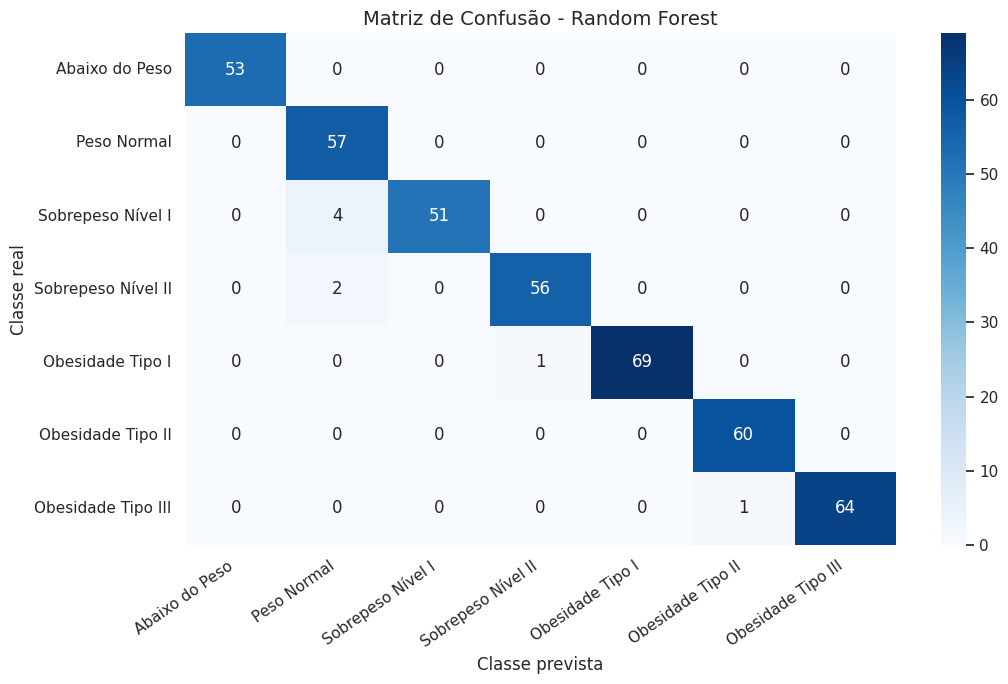

In [31]:
# Matriz de confusão
classes_ordenadas = ordem_obesidade
classes_pt = [traducao_classes[classe] for classe in classes_ordenadas]

matriz_confusao = confusion_matrix(
    y_test,
    y_pred_melhor,
    labels=classes_ordenadas
)

plt.figure(figsize=(11, 7))

sns.heatmap(
    matriz_confusao,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes_pt,
    yticklabels=classes_pt
)

plt.title(f"Matriz de Confusão - {melhor_modelo_nome}", fontsize=14)
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
# ROC AUC multiclasse
if hasattr(melhor_pipeline, "predict_proba"):

    y_proba = melhor_pipeline.predict_proba(X_test)
    classes_modelo = melhor_pipeline.named_steps["modelo"].classes_

    roc_auc_macro = roc_auc_score(
        y_test,
        y_proba,
        average="macro",
        multi_class="ovr",
        labels=classes_modelo
    )

    roc_auc_weighted = roc_auc_score(
        y_test,
        y_proba,
        average="weighted",
        multi_class="ovr",
        labels=classes_modelo
    )

    print(f"ROC AUC Macro: {roc_auc_macro:.4f}")
    print(f"ROC AUC Weighted: {roc_auc_weighted:.4f}")

else:
    roc_auc_macro = np.nan
    roc_auc_weighted = np.nan
    print("O modelo selecionado não possui predict_proba.")

ROC AUC Macro: 0.9999
ROC AUC Weighted: 0.9999


## 11. Validação adicional contra overfitting

Como o Random Forest apresentou desempenho muito elevado, foi feita uma validação adicional para avaliar possíveis sinais de overfitting.

Foram utilizadas duas verificações simples:

- comparação entre desempenho no conjunto de treino e no conjunto de teste;
- validação cruzada estratificada com 5 divisões.

Essa análise ajuda a verificar se o modelo mantém bom desempenho em dados não utilizados no treinamento, em vez de apenas memorizar os registros da base de treino.

In [33]:
# Comparação entre treino e teste
# O objetivo é verificar se existe uma diferença muito grande entre o desempenho nos dois conjuntos.

y_pred_train = melhor_pipeline.predict(X_train)
y_pred_test = melhor_pipeline.predict(X_test)

comparacao_overfitting = pd.DataFrame({
    "Base": ["Treino", "Teste"],
    "Acurácia": [
        accuracy_score(y_train, y_pred_train),
        accuracy_score(y_test, y_pred_test)
    ],
    "F1-score Macro": [
        f1_score(y_train, y_pred_train, average="macro"),
        f1_score(y_test, y_pred_test, average="macro")
    ]
})

comparacao_overfitting["Acurácia"] = (comparacao_overfitting["Acurácia"] * 100).round(2)
comparacao_overfitting["F1-score Macro"] = (comparacao_overfitting["F1-score Macro"] * 100).round(2)

display(comparacao_overfitting)

,Base,Acurácia,F1-score Macro
0,Treino,100.00,100.00
1,Teste,98.09,98.04


In [34]:
# Validação cruzada estratificada
# A validação cruzada avalia o modelo em diferentes divisões da base.

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas_cv = cross_validate(
    melhor_pipeline,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "f1_macro"],
    return_train_score=True
)

resultado_cv = pd.DataFrame({
    "Métrica": ["Acurácia", "F1-score Macro"],
    "Treino - Média": [
        metricas_cv["train_accuracy"].mean(),
        metricas_cv["train_f1_macro"].mean()
    ],
    "Teste CV - Média": [
        metricas_cv["test_accuracy"].mean(),
        metricas_cv["test_f1_macro"].mean()
    ],
    "Teste CV - Desvio": [
        metricas_cv["test_accuracy"].std(),
        metricas_cv["test_f1_macro"].std()
    ]
})

for coluna in ["Treino - Média", "Teste CV - Média", "Teste CV - Desvio"]:
    resultado_cv[coluna] = (resultado_cv[coluna] * 100).round(2)

display(resultado_cv)

,Métrica,Treino - Média,Teste CV - Média,Teste CV - Desvio
0,Acurácia,100.00,98.51,0.65
1,F1-score Macro,100.00,98.44,0.67


### Interpretação da validação

O desempenho em treino ficou superior ao desempenho em teste, o que é esperado em modelos supervisionados. No entanto, a diferença não foi suficiente para indicar um problema relevante de overfitting, pois o modelo manteve acurácia e F1-score macro elevados no conjunto de teste.

A validação cruzada estratificada reforçou essa leitura, com desempenho médio elevado nas divisões de teste. Portanto, os resultados indicam boa capacidade de generalização dentro da base utilizada.

A alta performance também deve ser interpretada com cautela: o conjunto de dados possui variáveis muito associadas ao nível de obesidade, especialmente peso, altura e IMC. Por isso, o resultado é coerente com o domínio do problema, mas não elimina a necessidade de validação futura com dados reais de produção.

## 12. Importância das variáveis

A importância das variáveis ajuda a explicar quais fatores mais contribuíram para as previsões do modelo final.

In [35]:
# Dicionário para tradução das variáveis
traducao_variaveis = {
    "BMI": "IMC",
    "Weight": "Peso",
    "Height": "Altura",
    "Age": "Idade",
    "FCVC": "Consumo de Vegetais",
    "NCP": "Refeições Principais",
    "CH2O": "Consumo de Água",
    "FAF": "Atividade Física",
    "TUE": "Uso de Tecnologia",
    "Gender_Female": "Gênero Feminino",
    "Gender_Male": "Gênero Masculino",
    "family_history_yes": "Histórico Familiar: Sim",
    "family_history_no": "Histórico Familiar: Não",
    "FAVC_yes": "Alimentos Calóricos: Sim",
    "FAVC_no": "Alimentos Calóricos: Não",
    "SMOKE_yes": "Fuma: Sim",
    "SMOKE_no": "Fuma: Não",
    "SCC_yes": "Monitora Calorias: Sim",
    "SCC_no": "Monitora Calorias: Não",
    "CAEC_Sometimes": "Lanches entre Refeições: Às vezes",
    "CAEC_Frequently": "Lanches entre Refeições: Frequentemente",
    "CAEC_Always": "Lanches entre Refeições: Sempre",
    "CAEC_no": "Lanches entre Refeições: Não",
    "CALC_Sometimes": "Álcool: Às vezes",
    "CALC_Frequently": "Álcool: Frequentemente",
    "CALC_Always": "Álcool: Sempre",
    "CALC_no": "Álcool: Não",
    "MTRANS_Automobile": "Transporte: Automóvel",
    "MTRANS_Bike": "Transporte: Bicicleta",
    "MTRANS_Motorbike": "Transporte: Moto",
    "MTRANS_Public_Transportation": "Transporte: Público",
    "MTRANS_Walking": "Transporte: Caminhada"
}

modelo_final = melhor_pipeline.named_steps["modelo"]

if hasattr(modelo_final, "feature_importances_"):

    nomes_num = variaveis_numericas

    encoder = (
        melhor_pipeline
        .named_steps["preprocessador"]
        .named_transformers_["cat"]
        .named_steps["onehot"]
    )

    nomes_cat = encoder.get_feature_names_out(variaveis_categoricas).tolist()
    nomes_features = nomes_num + nomes_cat

    importancia_df = pd.DataFrame({
        "variavel": nomes_features,
        "importancia": modelo_final.feature_importances_
    }).sort_values(by="importancia", ascending=False)

    importancia_df["variavel_traduzida"] = importancia_df["variavel"].map(
        lambda x: traducao_variaveis.get(x, x)
    )

    importancia_df["importancia_percentual"] = (
        importancia_df["importancia"] * 100
    ).round(2)

    display(importancia_df[["variavel_traduzida", "importancia_percentual"]].head(15))

else:
    importancia_df = pd.DataFrame()
    print("O modelo selecionado não possui feature_importances_.")

,variavel_traduzida,importancia_percentual
8,IMC,30.81
2,Peso,20.08
0,Idade,6.00
3,Consumo de Vegetais,5.80
1,Altura,5.24
4,Refeições Principais,3.29
10,Gênero Masculino,3.05
9,Gênero Feminino,2.81
7,Uso de Tecnologia,2.76
6,Atividade Física,2.74


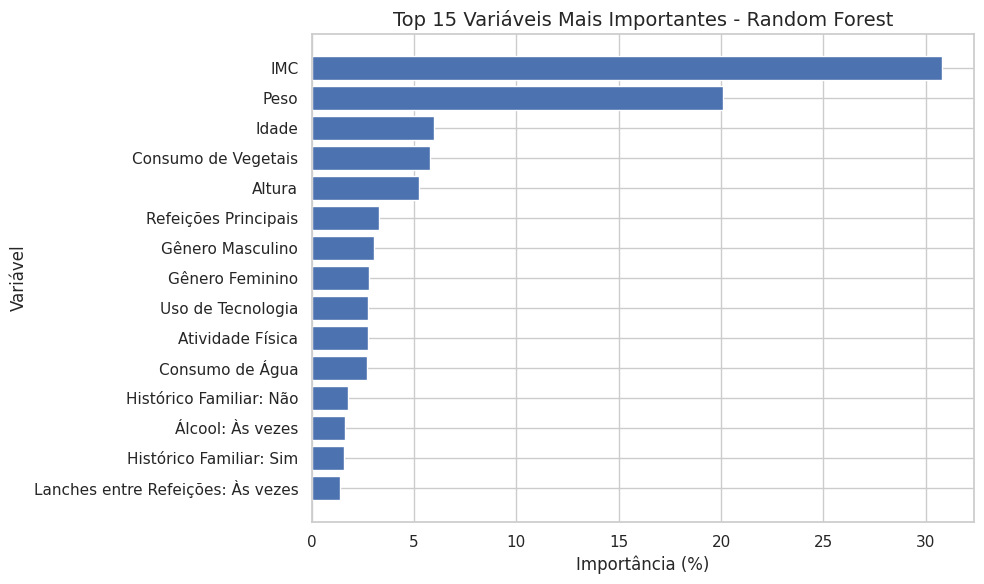

In [36]:
# Gráfico: top variáveis mais importantes
if not importancia_df.empty:

    plot_df = importancia_df.head(15).sort_values("importancia_percentual")

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["variavel_traduzida"], plot_df["importancia_percentual"])

    plt.title(f"Top 15 Variáveis Mais Importantes - {melhor_modelo_nome}", fontsize=14)
    plt.xlabel("Importância (%)")
    plt.ylabel("Variável")
    plt.tight_layout()
    plt.show()

## 13. Salvamento dos artefatos

A pipeline completa será salva para uso posterior no Streamlit. Também são salvos arquivos auxiliares com métricas, relatório de classificação, importância das variáveis e base tratada.

In [37]:
# Criação das pastas de saída
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("data", exist_ok=True)

# Salvamento da pipeline final
joblib.dump(melhor_pipeline, "models/modelo_obesidade.pkl")

# Salvamento dos arquivos auxiliares
df.to_csv("data/obesity_tratada.csv", index=False)
resultados_modelos.to_csv("outputs/comparacao_modelos.csv", index=False)
resultados_modelos_pt.to_csv("outputs/comparacao_modelos_pt.csv", index=False)
relatorio_df.to_csv("outputs/relatorio_classificacao.csv")
relatorio_df_pt.to_csv("outputs/relatorio_classificacao_pt.csv")

if not importancia_df.empty:
    importancia_df.to_csv("outputs/importancia_variaveis.csv", index=False)
    importancia_df[["variavel_traduzida", "importancia_percentual"]].to_csv(
        "outputs/importancia_variaveis_pt.csv",
        index=False
    )

print("Arquivos salvos com sucesso:")
print("- models/modelo_obesidade.pkl")
print("- data/obesity_tratada.csv")
print("- outputs/comparacao_modelos.csv")
print("- outputs/comparacao_modelos_pt.csv")
print("- outputs/relatorio_classificacao.csv")
print("- outputs/relatorio_classificacao_pt.csv")

if not importancia_df.empty:
    print("- outputs/importancia_variaveis.csv")
    print("- outputs/importancia_variaveis_pt.csv")

Arquivos salvos com sucesso:
- models/modelo_obesidade.pkl
- data/obesity_tratada.csv
- outputs/comparacao_modelos.csv
- outputs/comparacao_modelos_pt.csv
- outputs/relatorio_classificacao.csv
- outputs/relatorio_classificacao_pt.csv
- outputs/importancia_variaveis.csv
- outputs/importancia_variaveis_pt.csv


## 14. Conclusões

O projeto foi desenvolvido como um problema de classificação multiclasse, mantendo as sete classes originais da variável alvo `Obesity`.

O modelo final selecionado foi o Random Forest, que apresentou desempenho superior ao requisito mínimo de 75% de assertividade definido no desafio. A avaliação considerou acurácia, F1-score macro, relatório de classificação, matriz de confusão e ROC AUC multiclasse.

Como o desempenho foi elevado, foi realizada uma validação adicional para avaliar possíveis sinais de overfitting. A comparação entre treino e teste mostrou diferença pequena entre os resultados, e a validação cruzada estratificada manteve métricas elevadas em diferentes divisões da base. Dessa forma, não foram observados sinais relevantes de overfitting.

Ainda assim, a alta performance deve ser interpretada considerando a natureza do problema: a base possui variáveis fortemente relacionadas à classificação corporal, como peso, altura e IMC. O IMC foi criado como uma etapa de feature engineering e se mostrou a variável mais importante do modelo.

Como próximo passo, a pipeline salva será integrada a uma aplicação Streamlit, que irá conter o sistema preditivo e o dashboard analítico do projeto.

## 15. Download opcional dos arquivos gerados

No Colab, esta etapa pode ser usada para compactar os artefatos finais e facilitar o download.

In [38]:
# Etapa opcional para uso no Colab
# Compacta somente os artefatos necessários para o projeto final.

import shutil
from pathlib import Path

pasta_artefatos = Path("artefatos_finais")
pasta_artefatos.mkdir(exist_ok=True)

# Copiar pastas principais, substituindo versões anteriores se necessário
for pasta in ["models", "outputs", "data"]:
    destino = pasta_artefatos / pasta

    if destino.exists():
        shutil.rmtree(destino)

    shutil.copytree(pasta, destino)

# Gerar arquivo .zip com os artefatos finais
zip_nome = "artefatos_tech_challenge_fase_4"

if Path(zip_nome + ".zip").exists():
    Path(zip_nome + ".zip").unlink()

shutil.make_archive(
    zip_nome,
    "zip",
    root_dir=pasta_artefatos
)

print(f"Arquivo compactado gerado: {zip_nome}.zip")

Arquivo compactado gerado: artefatos_tech_challenge_fase_4.zip
